In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, average_precision_score, auc, roc_curve
import matplotlib.pyplot as plt

In [2]:
valid_labels = pd.read_csv('../../../results/PlantCAD2_tasks/exp-leaf-bin/valid.tsv', sep='\t')
test_labels = pd.read_csv('../../../results/PlantCAD2_tasks/exp-leaf-bin/test.tsv', sep='\t')

The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


In [3]:
model_dict = [
    ('pcv2_1', 'pcv2-l24-d0768-checkpoints-lr-1e-4'),
    ('pcv2_2', 'pcv2-l48-d1024-checkpoints-lr-1e-4'),
    ('pcv2_3', 'pcv2-l48-d1536-checkpoints-lr-1e-4'),
    ('agront', 'agront-checkpoints-lr-1e-4'),
    ('sup_pcv2_1', 'sup_pcv2-l24-d0768-checkpoints-lr-1e-4'),
    ('cnn_lstm', 'cnn_lstm'),
]

In [4]:
for model in model_dict:
    curPATH = f'../../../results/PlantCAD2_tasks/exp-leaf-bin/{model[1]}/valid_scores.tsv'
    curPreds = pd.read_csv(curPATH, sep='\t')
    valid_labels[f'{model[0]}'] = curPreds['probability_positive']

In [5]:
for model in model_dict:
    curPATH = f'../../../results/PlantCAD2_tasks/exp-leaf-bin/{model[1]}/predictions.csv'
    curPreds = pd.read_csv(curPATH, sep='\t')
    test_labels[f'{model[0]}'] = curPreds['probability_positive']

In [6]:
records = []
pcv2_alphas = [0.4, 0.7, 1.0]
for k, model in enumerate(model_dict):
    valid_preds = valid_labels[f'{model[0]}']
    test_preds = test_labels[f'{model[0]}']

    valid_true = valid_labels['Label']
    test_true = test_labels['Label']
    
    fpr, tpr, thresholds = roc_curve(valid_true, valid_preds)
    auc_valid = auc(fpr, tpr)
    ap_valid = average_precision_score(valid_true, valid_preds)
    
    fpr, tpr, thresholds = roc_curve(test_true, test_preds)
    auc_test = auc(fpr, tpr)
    ap_test = average_precision_score(test_true, test_preds)

    if 'agront' in model[0].lower():
        color, alpha = 'gray', 1.0
    elif 'sup_pcv2' in model[0].lower():
        color, alpha = 'C1', 1.0
    elif 'cnn' in model[0].lower():
        color, alpha = 'C1', 0.5
    else:
        color, alpha = 'C0', pcv2_alphas[k]

    if 'cnn' in model[0].lower():
        lab = model[0].replace('-imbalance-lr-1e-3', '')
    else:
        lab = model[0].replace('-checkpoints-lr-1e-4', '')

    records.append({
        'model': model[0],
        'label': 'valid',
        'ap': ap_valid,
        'auc': auc_valid,
        'color': color,
        'alpha': alpha,
        'baseline': valid_true.mean()
    })
    records.append({
        'model': model[0],
        'label': 'test',
        'ap': ap_test,
        'auc': auc_test,
        'color': color,
        'alpha': alpha,
        'baseline': test_true.mean()
    })

In [7]:
df = pd.DataFrame(records)

In [8]:
df.head()

,model,label,ap,auc,color,alpha,baseline
0,pcv2_1,valid,0.891302,0.800222,C0,0.4,0.686995
1,pcv2_1,test,0.938940,0.822076,C0,0.4,0.761315
2,pcv2_2,valid,0.903000,0.820003,C0,0.7,0.686995
3,pcv2_2,test,0.943400,0.833781,C0,0.7,0.761315
4,pcv2_3,valid,0.904221,0.820183,C0,1.0,0.686995


In [9]:
df.to_csv('auc_exp-leaf-bin.tsv', sep='\t', index=False)

In [10]:
models = df['model'].unique()
n_models = len(models)

species_order = ['valid', 'test']
n_sp = len(species_order)

bar_w = 0.8 / n_models
x = np.arange(n_sp)

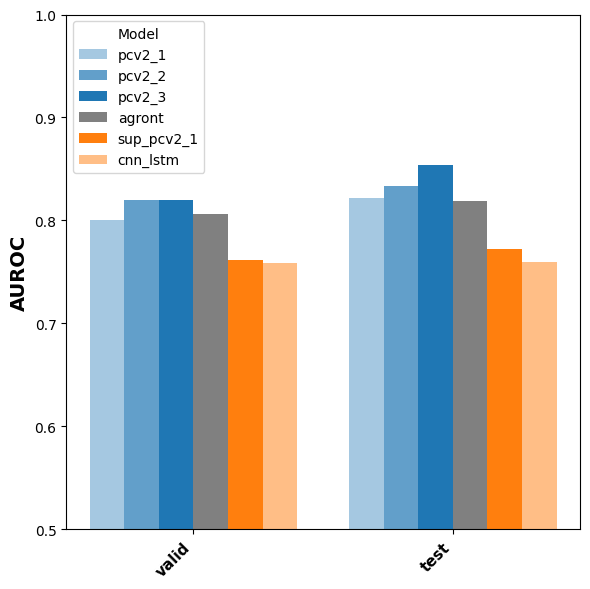

In [11]:
fig, ax = plt.subplots(figsize=(5 + 0.5 * n_sp, 6))

for i, model in enumerate(models):
    sub = df[df['model'] == model]
    sub = sub.set_index('label').reindex(species_order).reset_index()

    ax.bar(
        x + i * bar_w,
        sub['auc'],
        bar_w,
        label=model,
        color=sub['color'].iloc[0] if not sub.empty else 'gray',
        alpha=sub['alpha'].iloc[0] if not sub.empty else 0.5
    )

ax.set_xticks(x + bar_w * (n_models - 1) / 2)
ax.set_xticklabels(species_order, rotation=45, ha='right', fontsize=11, fontweight='bold')

ax.set_ylabel('AUROC', fontsize=14, fontweight='bold')
ax.set_ylim(0.5, 1.0)
ax.legend(title='Model', fontsize=10)

plt.tight_layout()
plt.savefig('auc_exp-leaf-bin.pdf', format='pdf', bbox_inches='tight')
plt.show()